# PHT3D Example 11 — MF6PQC benchmark

This notebook is self-contained: it loads the checked-in official PHT3D fields and the MF6PQC output, calculates the six quantities shown in the reference figure, reports numerical agreement, and renders the final figure inline. It does not write PNG or JPEG files.

In [2]:
import os
import sys
from pathlib import Path

sys.dont_write_bytecode = True
_name = "PHT3D_E11"
_candidates = [
    p for base in (Path.cwd(), *Path.cwd().parents) for p in (base, base / "examples" / _name)
]
CASE_DIR = next(
    (p.resolve() for p in _candidates if p.name == _name and (p / "modflow_model.py").is_file()),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{_name} from {Path.cwd()}")
os.chdir(CASE_DIR)
sys.path.insert(0, str(CASE_DIR))
__file__ = str(CASE_DIR / "plot.ipynb")
from modflow_model import runtime_path

OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"

# Saved numerical outputs are distributed losslessly; solver logs are omitted.
import zipfile

for _kind in ("output", "simulation"):
    _base = CASE_DIR / _kind
    for _archive in sorted(_base.glob("saved_results*.zip")):
        with zipfile.ZipFile(_archive) as _zip:
            for _member in _zip.infolist():
                _target = (_base / _member.filename).resolve()
                if not _target.is_relative_to(_base.resolve()):
                    raise ValueError("Archive member escapes the case directory")
                if not _target.exists():
                    _zip.extract(_member, _base)

In [3]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


def locate_case_directory():
    candidates = [Path.cwd(), Path.cwd() / "examples" / "PHT3D_E11"]
    for candidate in candidates:
        if (candidate / "input_data" / "official_reference.npz").is_file():
            return candidate.resolve()
    raise FileNotFoundError("Run this notebook from PHT3D_E11 or the repository root.")


CASE_DIR = locate_case_directory()
NLAY, NROW, NCOL = 58, 1, 99
DELR = np.array([1.0] * 7 + [0.5] * 2 + [0.25] * 76 + [0.5] * 2 + [1.0] * 12)
TOP = 34.2
BOTM = np.array(
    [34.15 - 0.05 * layer for layer in range(44)]
    + [31.75, 31.5, 31.25, 31.0, 30.5, 30.0]
    + list(np.arange(29.0, 21.0, -1.0))
)
X_CENTERS = np.cumsum(DELR) - 0.5 * DELR
LAYER_TOPS = np.r_[TOP, BOTM[:-1]]
Z_CENTERS = 0.5 * (LAYER_TOPS + BOTM)
X_GRID, Z_GRID = np.meshgrid(X_CENTERS, Z_CENTERS)

results = np.load(CASE_DIR / "output" / "results.npy")
result_times = np.load(CASE_DIR / "output" / "results_times.npy")
headings = [
    line.strip()
    for line in (CASE_DIR / "output" / "results_headings.txt")
    .read_text(encoding="utf-8")
    .splitlines()
    if line.strip()
]
expected_shape = (result_times.size, len(headings), NLAY * NROW * NCOL)
if results.shape != expected_shape:
    raise ValueError(f"Unexpected results shape {results.shape}; expected {expected_shape}.")
mf6pqc = results.reshape(result_times.size, len(headings), NLAY, NCOL)

with np.load(CASE_DIR / "input_data" / "official_reference.npz") as archive:
    reference = {name: archive[name].copy() for name in archive.files}

reference_times = reference.pop("time_days")
if not np.allclose(result_times, reference_times):
    raise ValueError(f"Output times {result_times} do not match PHT3D times {reference_times}.")
if not np.isclose(result_times[-1], 60.0):
    raise ValueError("The final benchmark figure requires the day-60 result.")

print(f"Loaded {result_times.size} states on a {NLAY} × {NROW} × {NCOL} grid.")
print(f"Final comparison time: {result_times[-1]:g} days")

Loaded 13 states on a 58 × 1 × 99 grid.
Final comparison time: 60 days


In [4]:
CARBON_STANDARD_RATIO = 0.0112372
SULFUR_STANDARD_RATIO = (1.021e-4 / 2.192e-3) / 1.010


def isotope_delta(light, heavy, standard_ratio, threshold, background_delta):
    total = light + heavy
    delta = np.full(total.shape, background_delta, dtype=float)
    valid = np.isfinite(light) & np.isfinite(heavy) & (total > threshold) & (light > 0.0)
    delta[valid] = (heavy[valid] / light[valid] / standard_ratio - 1.0) * 1000.0
    delta[~np.isfinite(total)] = np.nan
    return delta


def derive_fields(source):
    if source == "mf6pqc":

        def get(name):
            return mf6pqc[:, headings.index(name)]
    elif source == "pht3d":
        get = reference.__getitem__
    else:
        raise ValueError("source must be 'mf6pqc' or 'pht3d'")

    toluene = get("Tolu_l") + get("Tolu_h")
    naphthalene = get("Naph_l") + get("Naph_h")
    sulfate = get("Sulf_l_6") + get("Sulf_h_6")
    return {
        "Toluene": toluene,
        "delta13C Toluene": isotope_delta(
            get("Tolu_l"), get("Tolu_h"), CARBON_STANDARD_RATIO, 1.0e-8, -25.0
        ),
        "Naphthalene": naphthalene,
        "delta13C Naphthalene": isotope_delta(
            get("Naph_l"), get("Naph_h"), CARBON_STANDARD_RATIO, 1.0e-8, -25.0
        ),
        "Sulfate": sulfate,
        "delta34S Sulfate": isotope_delta(
            get("Sulf_l_6"), get("Sulf_h_6"), SULFUR_STANDARD_RATIO, 1.0e-12, 10.0
        ),
    }


mf_fields = derive_fields("mf6pqc")
pht3d_fields = derive_fields("pht3d")
wet_mask = np.isfinite(reference["Sulf_l_6"][-1])

## Numerical agreement at day 60

The comparison domain is exactly the visible reference-figure window ($4 \le x \le 36$ m and $32.5 \le z \le 34.15$ m). Concentration RMSE is normalized by the corresponding color range; isotope RMSE is reported in per mil after applying the same displayed color limits. The latter prevents out-of-frame boundary noise and ratios outside the plotted scale from dominating a figure-agreement metric. Organic isotope statistics exclude cells where the official total concentration is below $10^{-8}$ mol/L.

In [5]:
metric_specs = [
    ("Toluene", (0.0, 1.0e-3), 1.0e-3, None),
    ("delta13C Toluene", (-25.0, -18.0), None, pht3d_fields["Toluene"][-1] > 1.0e-8),
    ("Naphthalene", (0.0, 4.0e-4), 4.0e-4, None),
    ("delta13C Naphthalene", (-25.0, -18.0), None, pht3d_fields["Naphthalene"][-1] > 1.0e-8),
    ("Sulfate", (0.0, 3.0e-3), 3.0e-3, None),
    ("delta34S Sulfate", (10.0, 60.0), None, None),
]
well_column = int(np.argmin(np.abs(X_CENTERS - 24.0)))
figure_mask = wet_mask & (X_GRID >= 4.0) & (X_GRID <= 36.0) & (Z_GRID >= 32.5) & (Z_GRID <= 34.15)
profile_domain = (Z_CENTERS >= 32.5) & (Z_CENTERS <= 34.15) & wet_mask[:, well_column]
rows = []
for name, limits, concentration_scale, extra_mask in metric_specs:
    reproduced = np.clip(mf_fields[name][-1], *limits)
    official = np.clip(pht3d_fields[name][-1], *limits)
    field_mask = figure_mask & np.isfinite(reproduced) & np.isfinite(official)
    profile_mask = profile_domain.copy()
    if extra_mask is not None:
        field_mask &= extra_mask
        profile_mask &= extra_mask[:, well_column]
    field_rmse = float(np.sqrt(np.mean((reproduced[field_mask] - official[field_mask]) ** 2)))
    profile_rmse = float(
        np.sqrt(
            np.mean(
                (reproduced[:, well_column][profile_mask] - official[:, well_column][profile_mask])
                ** 2
            )
        )
    )
    if concentration_scale is not None:
        field_rmse = 100.0 * field_rmse / concentration_scale
        profile_rmse = 100.0 * profile_rmse / concentration_scale
    rows.append(
        {
            "quantity": name.replace("delta13C", "δ¹³C").replace("delta34S", "δ³⁴S"),
            "field RMSE": field_rmse,
            "HR-MLW RMSE": profile_rmse,
            "unit": "‰" if concentration_scale is None else "% of color range",
            "compared cells": int(field_mask.sum()),
        }
    )

metrics = pd.DataFrame(rows).set_index("quantity")
display(metrics.style.format({"field RMSE": "{:.3f}", "HR-MLW RMSE": "{:.3f}"}))

,field RMSE,HR-MLW RMSE,unit,compared cells
quantity,,,,
Toluene,0.577,0.537,% of color range,2557
δ¹³C Toluene,0.064,0.054,‰,2281
Naphthalene,0.588,0.583,% of color range,2557
δ¹³C Naphthalene,0.069,0.017,‰,2249
Sulfate,0.779,0.856,% of color range,2557
δ³⁴S Sulfate,0.218,0.266,‰,2557


## Day-60 contour and HR-MLW comparison

Filled contours are MF6PQC. At the HR-MLW location ($x=24$ m), the white curve is the official PHT3D profile and red open circles are MF6PQC values mapped onto the same horizontal profile scale. Agreement appears as red circles lying on the white curve.

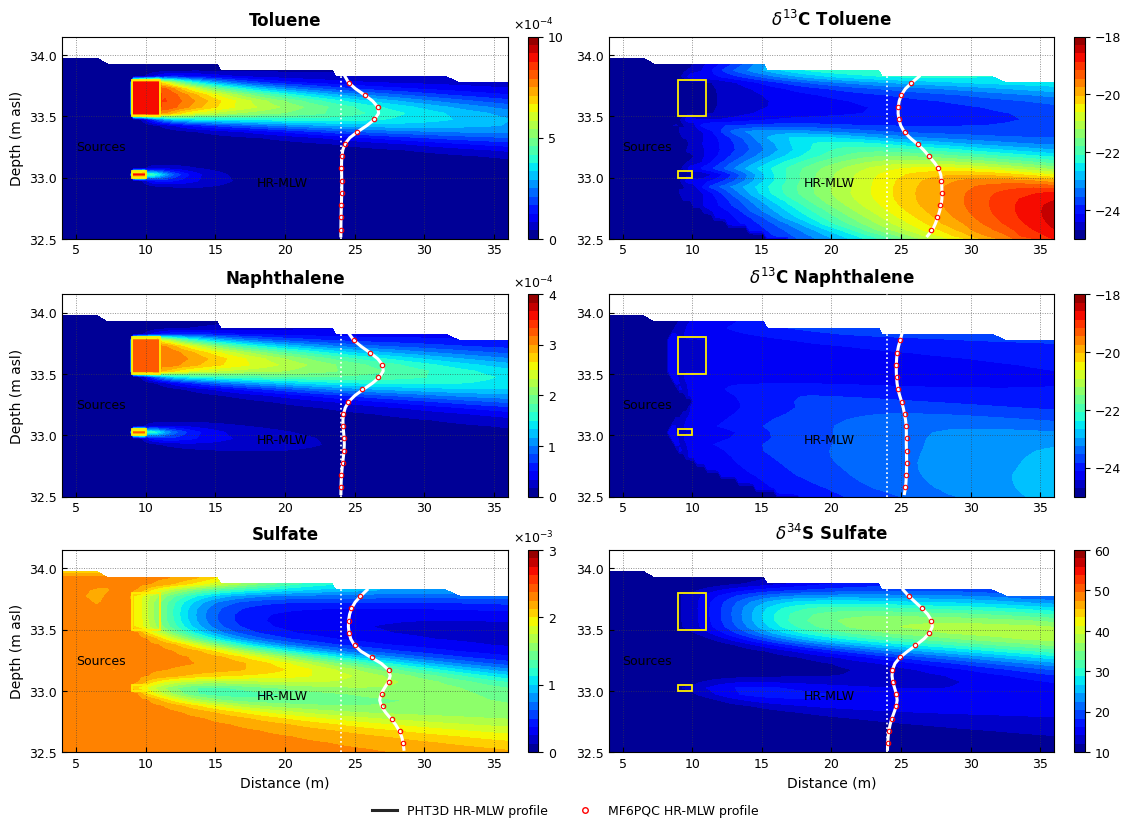

In [6]:
plot_specs = [
    {
        "name": "Toluene",
        "title": "Toluene",
        "scale": 1.0e4,
        "limits": (0.0, 10.0),
        "ticks": [0, 5, 10],
        "exponent": r"$\times 10^{-4}$",
    },
    {
        "name": "delta13C Toluene",
        "title": r"$\delta^{13}$C Toluene",
        "scale": 1.0,
        "limits": (-25.0, -18.0),
        "ticks": [-24, -22, -20, -18],
        "exponent": None,
    },
    {
        "name": "Naphthalene",
        "title": "Naphthalene",
        "scale": 1.0e4,
        "limits": (0.0, 4.0),
        "ticks": [0, 1, 2, 3, 4],
        "exponent": r"$\times 10^{-4}$",
    },
    {
        "name": "delta13C Naphthalene",
        "title": r"$\delta^{13}$C Naphthalene",
        "scale": 1.0,
        "limits": (-25.0, -18.0),
        "ticks": [-24, -22, -20, -18],
        "exponent": None,
    },
    {
        "name": "Sulfate",
        "title": "Sulfate",
        "scale": 1.0e3,
        "limits": (0.0, 3.0),
        "ticks": [0, 1, 2, 3],
        "exponent": r"$\times 10^{-3}$",
    },
    {
        "name": "delta34S Sulfate",
        "title": r"$\delta^{34}$S Sulfate",
        "scale": 1.0,
        "limits": (10.0, 60.0),
        "ticks": [10, 20, 30, 40, 50, 60],
        "exponent": None,
    },
]

PROFILE_X0, PROFILE_WIDTH = 24.0, 6.0
profile_layers = (Z_CENTERS >= 32.5) & (Z_CENTERS <= 34.0) & wet_mask[:, well_column]
profile_marker_layers = profile_layers & (np.arange(NLAY) % 2 == 0)


def add_case_annotations(ax):
    ax.add_patch(
        Rectangle((9.0, 33.5), 2.0, 0.3, fill=False, edgecolor="#ffef00", linewidth=1.3, zorder=8)
    )
    ax.add_patch(
        Rectangle((9.0, 33.0), 1.0, 0.05, fill=False, edgecolor="#ffef00", linewidth=1.3, zorder=8)
    )
    ax.axvline(PROFILE_X0, color="white", linestyle=":", linewidth=1.25, zorder=7)
    ax.text(5.0, 33.22, "Sources", fontsize=9, color="black", zorder=9)
    ax.text(18.0, 32.93, "HR-MLW", fontsize=9, color="black", zorder=9)


fig, axes = plt.subplots(3, 2, figsize=(11.2, 8.2), constrained_layout=True)
for panel, (ax, spec) in enumerate(zip(axes.flat, plot_specs, strict=False)):
    low, high = spec["limits"]
    reproduced = mf_fields[spec["name"]][-1] * spec["scale"]
    official = pht3d_fields[spec["name"]][-1] * spec["scale"]
    clipped = np.clip(reproduced, low, high).astype(float)
    clipped[~wet_mask] = np.nan
    levels = np.linspace(low, high, 25)
    contour = ax.contourf(X_GRID, Z_GRID, clipped, levels=levels, cmap="jet")

    official_profile = np.clip(official[:, well_column], low, high)
    reproduced_profile = np.clip(reproduced[:, well_column], low, high)
    official_x = PROFILE_X0 + PROFILE_WIDTH * (official_profile - low) / (high - low)
    reproduced_x = PROFILE_X0 + PROFILE_WIDTH * (reproduced_profile - low) / (high - low)
    ax.plot(
        official_x[profile_layers],
        Z_CENTERS[profile_layers],
        color="white",
        linewidth=2.2,
        zorder=9,
    )
    ax.plot(
        reproduced_x[profile_marker_layers],
        Z_CENTERS[profile_marker_layers],
        linestyle="none",
        marker="o",
        markersize=3.2,
        markerfacecolor="none",
        markeredgecolor="red",
        markeredgewidth=0.8,
        zorder=10,
    )
    add_case_annotations(ax)

    ax.set_title(spec["title"], fontsize=12, fontweight="semibold", pad=8)
    ax.set_xlim(4.0, 36.0)
    ax.set_ylim(32.5, 34.15)
    ax.set_xticks(np.arange(5, 36, 5))
    ax.set_yticks([32.5, 33.0, 33.5, 34.0])
    ax.grid(True, color="0.25", linestyle=":", linewidth=0.65, alpha=0.65)
    ax.tick_params(direction="in", labelsize=9)
    if panel // 2 == 2:
        ax.set_xlabel("Distance (m)", fontsize=10)
    if panel % 2 == 0:
        ax.set_ylabel("Depth (m asl)", fontsize=10)

    colorbar = fig.colorbar(contour, ax=ax, ticks=spec["ticks"], fraction=0.050, pad=0.045)
    colorbar.ax.tick_params(labelsize=9)
    if spec["exponent"]:
        colorbar.ax.set_title(spec["exponent"], fontsize=9, pad=5)

legend_handles = [
    Line2D([0], [0], color="0.15", linewidth=2.2, label="PHT3D HR-MLW profile"),
    Line2D(
        [0],
        [0],
        linestyle="none",
        marker="o",
        markersize=4,
        markerfacecolor="none",
        markeredgecolor="red",
        label="MF6PQC HR-MLW profile",
    ),
]
fig.legend(handles=legend_handles, loc="outside lower center", ncol=2, frameon=False, fontsize=9)
plt.show()

## 数值核对

只检查已有结果，不启动模型。

In [7]:
"""Validate the E11 reproduction against the checked-in PHT3D fields."""


import sys
from pathlib import Path

import numpy as np

CASE_DIR = CASE_DIR


REPOSITORY_DIR = CASE_DIR.parents[1]


from modflow_model import BOTM, DELR, NCOL, NLAY, TOP

CARBON_STANDARD_RATIO = 0.0112372


SULFUR_STANDARD_RATIO = (1.021e-4 / 2.192e-3) / 1.010


ORGANIC_DISPLAY_THRESHOLD = 1.0e-8


PROFILE_X = 24.0


DISPLAY_SPECS = (
    ("Toluene", (0.0, 1.0e-3), 1.0e-3),
    ("delta13C Toluene", (-25.0, -18.0), None),
    ("Naphthalene", (0.0, 4.0e-4), 4.0e-4),
    ("delta13C Naphthalene", (-25.0, -18.0), None),
    ("Sulfate", (0.0, 3.0e-3), 3.0e-3),
    ("delta34S Sulfate", (10.0, 60.0), None),
)


REGRESSION_LIMITS: dict[str, tuple[float, float]] = {
    "Toluene": (1.0, 1.0),
    "delta13C Toluene": (0.2, 0.2),
    "Naphthalene": (1.0, 1.0),
    "delta13C Naphthalene": (0.2, 0.2),
    "Sulfate": (1.2, 1.2),
    "delta34S Sulfate": (0.4, 0.4),
}


def isotope_delta_section9(
    light: np.ndarray,
    heavy: np.ndarray,
    standard_ratio: float,
    threshold: float,
    background_delta: float,
) -> np.ndarray:
    """Return isotope delta while masking ratios below the display threshold."""
    total = light + heavy
    delta = np.full(total.shape, background_delta, dtype=float)
    valid = np.isfinite(light) & np.isfinite(heavy) & (total > threshold) & (light > 0.0)
    delta[valid] = (heavy[valid] / light[valid] / standard_ratio - 1.0) * 1000.0
    delta[~np.isfinite(total)] = np.nan
    return delta


def derive_fields_section9(source: dict[str, np.ndarray]) -> dict[str, np.ndarray]:
    """Derive the six quantities displayed in the published E11 figure."""
    toluene = source["Tolu_l"] + source["Tolu_h"]
    naphthalene = source["Naph_l"] + source["Naph_h"]
    sulfate = source["Sulf_l_6"] + source["Sulf_h_6"]
    return {
        "Toluene": toluene,
        "delta13C Toluene": isotope_delta_section9(
            source["Tolu_l"],
            source["Tolu_h"],
            CARBON_STANDARD_RATIO,
            ORGANIC_DISPLAY_THRESHOLD,
            -25.0,
        ),
        "Naphthalene": naphthalene,
        "delta13C Naphthalene": isotope_delta_section9(
            source["Naph_l"],
            source["Naph_h"],
            CARBON_STANDARD_RATIO,
            ORGANIC_DISPLAY_THRESHOLD,
            -25.0,
        ),
        "Sulfate": sulfate,
        "delta34S Sulfate": isotope_delta_section9(
            source["Sulf_l_6"],
            source["Sulf_h_6"],
            SULFUR_STANDARD_RATIO,
            1.0e-12,
            10.0,
        ),
    }


def grid_centres() -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return E11 x/z centres and their 2-D mesh."""
    x = np.cumsum(DELR) - 0.5 * DELR
    layer_tops = np.r_[TOP, BOTM[:-1]]
    z = 0.5 * (layer_tops + BOTM)
    x_grid, z_grid = np.meshgrid(x, z)
    return x, z, x_grid, z_grid


def load_case_fields() -> tuple[
    np.ndarray,
    dict[str, np.ndarray],
    dict[str, np.ndarray],
    dict[str, np.ndarray],
]:
    """Load MF6PQC and official arrays and return their derived fields."""
    output_dir = runtime_path(__file__, "output")
    results = np.load(output_dir / "results.npy")
    result_times = np.load(output_dir / "results_times.npy")
    headings = [
        line.strip()
        for line in (output_dir / "results_headings.txt").read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    expected_shape = (result_times.size, len(headings), NLAY * NCOL)
    if results.shape != expected_shape:
        raise AssertionError(f"Unexpected result shape {results.shape}; expected {expected_shape}")
    if not np.all(np.isfinite(results)):
        raise AssertionError("MF6PQC results contain non-finite values")

    reshaped = results.reshape(result_times.size, len(headings), NLAY, NCOL)
    model = {name: reshaped[:, index] for index, name in enumerate(headings)}
    with np.load(CASE_DIR / "input_data" / "official_reference.npz") as archive:
        reference = {name: archive[name].copy() for name in archive.files}
    reference_times = reference.pop("time_days")
    np.testing.assert_allclose(result_times, reference_times, rtol=0.0, atol=1.0e-10)
    if not np.isclose(result_times[-1], 60.0):
        raise AssertionError("The E11 benchmark requires the day-60 result")
    return result_times, model, derive_fields_section9(model), derive_fields_section9(reference)


def comparison_metrics() -> list[dict[str, float | int | str]]:
    """Calculate displayed-field and HR-MLW profile RMSE values."""
    _, model, model_fields, reference_fields = load_case_fields()
    x, z, x_grid, z_grid = grid_centres()
    well_column = int(np.argmin(np.abs(x - PROFILE_X)))
    wet = np.isfinite(reference_fields["Sulfate"][-1])
    figure_mask = wet & (x_grid >= 4.0) & (x_grid <= 36.0) & (z_grid >= 32.5) & (z_grid <= 34.15)
    profile_domain = (z >= 32.5) & (z <= 34.15) & wet[:, well_column]

    rows: list[dict[str, float | int | str]] = []
    for name, limits, concentration_scale in DISPLAY_SPECS:
        reproduced = np.clip(model_fields[name][-1], *limits)
        official = np.clip(reference_fields[name][-1], *limits)
        field_mask = figure_mask & np.isfinite(reproduced) & np.isfinite(official)
        profile_mask = profile_domain.copy()
        if name.startswith("delta13C"):
            concentration_name = name.removeprefix("delta13C ")
            organic_mask = reference_fields[concentration_name][-1] > ORGANIC_DISPLAY_THRESHOLD
            field_mask &= organic_mask
            profile_mask &= organic_mask[:, well_column]

        field_error = reproduced[field_mask] - official[field_mask]
        profile_error = (
            reproduced[:, well_column][profile_mask] - official[:, well_column][profile_mask]
        )
        field_rmse = float(np.sqrt(np.mean(field_error**2)))
        profile_rmse = float(np.sqrt(np.mean(profile_error**2)))
        unit = "per mil"
        if concentration_scale is not None:
            field_rmse = 100.0 * field_rmse / concentration_scale
            profile_rmse = 100.0 * profile_rmse / concentration_scale
            unit = "% colour range"
        rows.append(
            {
                "name": name,
                "field_rmse": field_rmse,
                "profile_rmse": profile_rmse,
                "unit": unit,
                "cells": int(field_mask.sum()),
            }
        )
    return rows


def validate_saved_results() -> None:
    rows = comparison_metrics()
    print("Official PHT3D day-60 comparison")
    print(f"{'quantity':<26} {'field RMSE':>12} {'HR-MLW RMSE':>14} {'unit':>15} {'cells':>7}")
    for row in rows:
        print(
            f"{row['name']:<26} {row['field_rmse']:12.4f} "
            f"{row['profile_rmse']:14.4f} {row['unit']:>15} "
            f"{row['cells']:7d}"
        )
        if row["name"] in REGRESSION_LIMITS:
            field_limit, profile_limit = REGRESSION_LIMITS[row["name"]]
            if row["field_rmse"] > field_limit:
                raise AssertionError(f"{row['name']} field RMSE exceeds its limit")
            if row["profile_rmse"] > profile_limit:
                raise AssertionError(f"{row['name']} HR-MLW RMSE exceeds its limit")
    print("PHT3D_E11 validation passed.")


validate_saved_results()

Official PHT3D day-60 comparison
quantity                     field RMSE    HR-MLW RMSE            unit   cells
Toluene                          0.5774         0.5372  % colour range    2557
delta13C Toluene                 0.0636         0.0543         per mil    2281
Naphthalene                      0.5881         0.5830  % colour range    2557
delta13C Naphthalene             0.0692         0.0172         per mil    2249
Sulfate                          0.7793         0.8557  % colour range    2557
delta34S Sulfate                 0.2184         0.2661         per mil    2557
PHT3D_E11 validation passed.
